In [208]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity

In [209]:
# Task 1.3
df = pd.read_csv(r"D:\SapphireWork\data\raw\dirty_cafe_sales.csv")
df

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2,2.0,4.0,NaN,UNKNOWN,2023-08-30
9996,TXN_9659401,NaN,3,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3,NaN,3.0,Digital Wallet,NaN,2023-12-02


In [210]:
df.isna().sum()

Transaction ID         0
Item                 333
Quantity             138
Price Per Unit       179
Total Spent          173
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64

In [211]:
# checking information of data
df.info()
df.shape
df.head()
df.describe()

# Columns represent the Attributes we have in our data, and
# Rows represent entries for those attributes.

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    10000 non-null  str  
 1   Item              9667 non-null   str  
 2   Quantity          9862 non-null   str  
 3   Price Per Unit    9821 non-null   str  
 4   Total Spent       9827 non-null   str  
 5   Payment Method    7421 non-null   str  
 6   Location          6735 non-null   str  
 7   Transaction Date  9841 non-null   str  
dtypes: str(8)
memory usage: 625.1 KB


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
count,10000,9667,9862,9821,9827,7421,6735,9841
unique,10000,10,7,8,19,5,4,367
top,TXN_1961373,Juice,5,3.0,6.0,Digital Wallet,Takeaway,UNKNOWN
freq,1,1171,2013,2429,979,2291,3022,159


In [212]:
# Checking Duplicates
df.duplicated().sum()

df = df.drop_duplicates()

In [213]:
# data type change krrahy ham, from str (object) to suitable while removing things
df["Transaction ID"] = df["Transaction ID"].astype(str).str.strip().astype("string")
df["Item"] = df["Item"].astype(str).str.strip().astype("string")
df["Payment Method"] = df["Payment Method"].astype(str).str.strip().astype("category")
df["Location"] = df["Location"].astype(str).str.strip().astype("string")

for col in ["Quantity", "Price Per Unit", "Total Spent"]:
    df[col] = df[col].astype(str).str.replace(r"[$,\s]", "", regex=True)

df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce").astype("Int64")
df["Price Per Unit"] = pd.to_numeric(df["Price Per Unit"], errors="coerce")
df["Total Spent"] = pd.to_numeric(df["Total Spent"], errors="coerce")

df["Transaction Date"] = pd.to_datetime(df["Transaction Date"], errors="coerce")

In [214]:
# Handling duplicates
# transform, group ky hisaab se koi bhi aggregate function lagasktay,
# yaha price per unit mai, i used median as its continuous and
# using mean would make the missing values will create more peaks

# price
df["Price Per Unit"] = df["Price Per Unit"].fillna(
        df.groupby("Item")["Price Per Unit"].transform("median")
)

df["Price Per Unit"] = df["Price Per Unit"].fillna(
    df["Price Per Unit"].median()
)

# quantity
df["Quantity"] = df["Quantity"].fillna(
    df.groupby("Item")["Quantity"].transform("median")
)

df["Quantity"] = df["Quantity"].fillna(1)

# total spent
df["Total Spent"] = df["Total Spent"].fillna(
    df["Quantity"] * df["Price Per Unit"]
)

# fill missing text 
df["Location"] = df["Location"].fillna("Unknown")
df["Item"] = df["Item"].fillna("Unknown")

# add 'Unknown' as category for Nan values
df["Payment Method"] = df["Payment Method"].cat.add_categories("Unknown")
df["Payment Method"] = df["Payment Method"].fillna("Unknown")

# transaciton date
df = df.sort_values(by="Transaction Date")
df["Transaction Date"] = df["Transaction Date"].ffill().bfill()

# error aur UNKNOWN ko 'Unknown' krna for similar naming for missing values
df["Location"] = df["Location"].astype(str).str.strip().str.upper()
df["Location"] = df["Location"].replace(["UNKNOWN", "ERROR"], "Unknown")
df["Location"] = df["Location"].astype("string")

df["Payment Method"] = df["Payment Method"].astype(str).str.strip().str.upper()
df["Payment Method"] = df["Payment Method"].replace(["UNKNOWN", "ERROR"], "Unknown")

df["Payment Method"] = df["Payment Method"].astype("category")

df["Item"] = df["Item"].astype(str).str.strip().str.title()
df["Item"] = df["Item"].replace(["Unknown", "Error", "Nan"], "Unknown")



In [215]:
df.info()
df.shape
df.head()
df.describe()

<class 'pandas.DataFrame'>
Index: 10000 entries, 8015 to 9988
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    10000 non-null  string        
 1   Item              10000 non-null  str           
 2   Quantity          10000 non-null  Int64         
 3   Price Per Unit    10000 non-null  float64       
 4   Total Spent       10000 non-null  float64       
 5   Payment Method    10000 non-null  category      
 6   Location          10000 non-null  string        
 7   Transaction Date  10000 non-null  datetime64[us]
dtypes: Int64(1), category(1), datetime64[us](1), float64(2), str(1), string(2)
memory usage: 644.6 KB


,Quantity,Price Per Unit,Total Spent,Transaction Date
count,10000.0,10000.000000,10000.000000,10000
mean,3.0235,2.947950,8.930450,2023-07-10 07:58:56.640000
min,1.0,1.000000,1.000000,2023-01-01 00:00:00
25%,2.0,2.000000,4.000000,2023-04-06 00:00:00
50%,3.0,3.000000,8.000000,2023-07-11 00:00:00
75%,4.0,4.000000,12.000000,2023-10-15 00:00:00
max,5.0,5.000000,25.000000,2023-12-31 00:00:00
std,1.387278,1.277196,6.000432,NaN


In [216]:
df

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
8015,TXN_4801947,Juice,1,3.0,3.0,DIGITAL WALLET,TAKEAWAY,2023-01-01
9063,TXN_9161256,Smoothie,2,4.0,8.0,DIGITAL WALLET,IN-STORE,2023-01-01
7309,TXN_6093955,Tea,5,1.5,7.5,Unknown,TAKEAWAY,2023-01-01
1425,TXN_8842223,Sandwich,5,4.0,20.0,DIGITAL WALLET,IN-STORE,2023-01-01
1777,TXN_7367474,Juice,5,3.0,15.0,DIGITAL WALLET,TAKEAWAY,2023-01-01
...,...,...,...,...,...,...,...,...
9933,TXN_9460419,Cake,1,3.0,3.0,Unknown,TAKEAWAY,2023-12-31
9937,TXN_8253472,Cake,1,3.0,3.0,Unknown,Unknown,2023-12-31
9949,TXN_3130865,Juice,3,3.0,9.0,Unknown,IN-STORE,2023-12-31
9983,TXN_9226047,Smoothie,3,4.0,12.0,CASH,Unknown,2023-12-31


In [217]:
df.sort_values(by="Item")


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
9988,TXN_9594133,Cake,5,3.0,15.0,Unknown,Unknown,2023-12-31
6989,TXN_4878020,Cake,3,3.0,9.0,Unknown,IN-STORE,2023-03-17
7591,TXN_9486849,Cake,3,3.0,3.0,CASH,TAKEAWAY,2023-03-17
4605,TXN_7683607,Cake,1,3.0,3.0,CASH,Unknown,2023-03-17
9863,TXN_6017034,Cake,4,3.0,12.0,Unknown,Unknown,2023-10-06
...,...,...,...,...,...,...,...,...
8449,TXN_1998143,Unknown,1,1.0,1.0,DIGITAL WALLET,IN-STORE,2023-12-10
9226,TXN_7340284,Unknown,5,1.0,5.0,Unknown,TAKEAWAY,2023-09-05
4872,TXN_9843421,Unknown,3,3.0,9.0,Unknown,IN-STORE,2023-09-06
6970,TXN_6034596,Unknown,1,5.0,5.0,Unknown,TAKEAWAY,2023-04-07


In [218]:
df[df["Item"] == "Unknown"]

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
2557,TXN_2690222,Unknown,4,3.0,12.0,Unknown,Unknown,2023-01-01
1045,TXN_6868182,Unknown,5,4.0,20.0,CREDIT CARD,Unknown,2023-01-02
5192,TXN_1298084,Unknown,2,1.5,3.0,CREDIT CARD,TAKEAWAY,2023-01-02
241,TXN_3205009,Unknown,2,1.5,3.0,CASH,IN-STORE,2023-01-03
7819,TXN_9014681,Unknown,3,4.0,12.0,Unknown,IN-STORE,2023-01-03
...,...,...,...,...,...,...,...,...
9454,TXN_1637131,Unknown,4,3.0,6.0,CASH,Unknown,2023-12-31
9600,TXN_7915173,Unknown,3,1.0,3.0,CASH,TAKEAWAY,2023-12-31
9610,TXN_4569448,Unknown,1,3.0,3.0,Unknown,Unknown,2023-12-31
9764,TXN_1688292,Unknown,3,3.0,9.0,CREDIT CARD,IN-STORE,2023-12-31


In [219]:
print(df["Item"].value_counts().head(5))

# most sold
print(df.groupby("Item")["Total Spent"].sum().sort_values(ascending=False).head(5))


Item
Juice       1171
Coffee      1165
Salad       1148
Cake        1139
Sandwich    1131
Name: count, dtype: int64
Item
Salad       17375.0
Sandwich    13764.0
Smoothie    13368.0
Juice       10542.0
Cake        10413.0
Name: Total Spent, dtype: float64


In [220]:
# payment method ka trend kia hai
print(df["Payment Method"].value_counts(normalize=True) * 100)

# top sales wali location
print(df.groupby("Location")["Total Spent"].sum().sort_values(ascending=False))


Payment Method
Unknown           31.78
DIGITAL WALLET    22.91
CREDIT CARD       22.73
CASH              22.58
Name: proportion, dtype: float64
Location
Unknown     35435.5
IN-STORE    27256.5
TAKEAWAY    26612.5
Name: Total Spent, dtype: float64


In [221]:
# har month ki total sale kitni, (dt, str, etc unky specific functions lagana allow krty)
monthly_sales = df.groupby(df["Transaction Date"].dt.to_period("M"))["Total Spent"].sum()
print(monthly_sales)


Transaction Date
2023-01     7284.0
2023-02     6656.0
2023-03     7225.0
2023-04     7203.0
2023-05     7011.5
2023-06     7359.0
2023-07     6885.0
2023-08     7115.5
2023-09     6889.0
2023-10     7326.0
2023-11     6967.0
2023-12    11383.5
Freq: M, Name: Total Spent, dtype: float64


In [222]:
# Engineer features
df["Month"] = df["Transaction Date"].dt.to_period("M")
print(df["Month"])

df["Day Of Week"] = df["Transaction Date"].dt.to_period("D")
print(df["Day Of Week"])

8015    2023-01
9063    2023-01
7309    2023-01
1425    2023-01
1777    2023-01
         ...   
9933    2023-12
9937    2023-12
9949    2023-12
9983    2023-12
9988    2023-12
Name: Month, Length: 10000, dtype: period[M]
8015    2023-01-01
9063    2023-01-01
7309    2023-01-01
1425    2023-01-01
1777    2023-01-01
           ...    
9933    2023-12-31
9937    2023-12-31
9949    2023-12-31
9983    2023-12-31
9988    2023-12-31
Name: Day Of Week, Length: 10000, dtype: period[D]


Month helps analyze seasonal sales trends, and Day of Week helps compare weekend vs weekday traffic.

In [223]:
print(df["Price Per Unit"].value_counts(bins=5).sort_index())

(0.995, 1.8]    2408
(1.8, 2.6]      1284
(2.6, 3.4]      2598
(3.4, 4.2]      2440
(4.2, 5.0]      1270
Name: count, dtype: int64


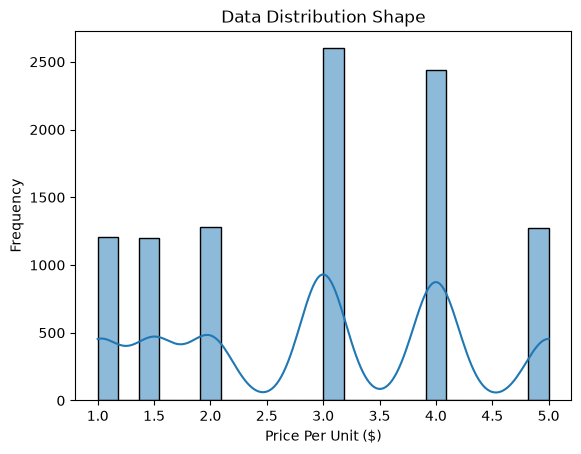

In [224]:
sns.histplot(df["Price Per Unit"].dropna(), kde=True)
plt.title("Data Distribution Shape")
plt.xlabel("Price Per Unit ($)")
plt.ylabel("Frequency")
plt.show()

I learnt that we can combine sns with matplotlib,
The data has 2 peaks.

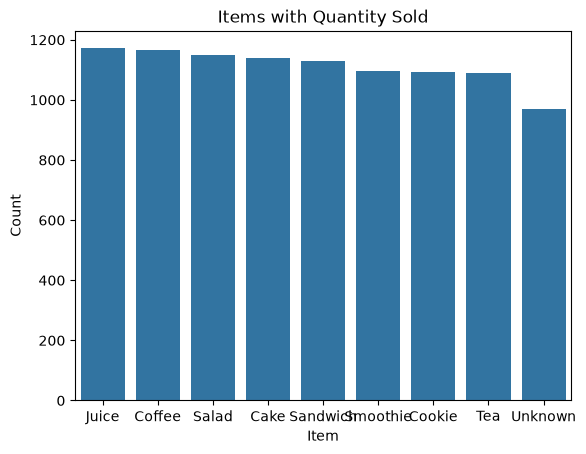

In [225]:
counts = df["Item"].value_counts()
sns.barplot(x=counts.index, y=counts.values)
plt.title("Items with Quantity Sold")
plt.xlabel("Item")
plt.ylabel("Count")
plt.show()

Even though items like Cake and Sandwich sell less frequently than Coffee, their higher price point drives a substantial portion of overall revenue.

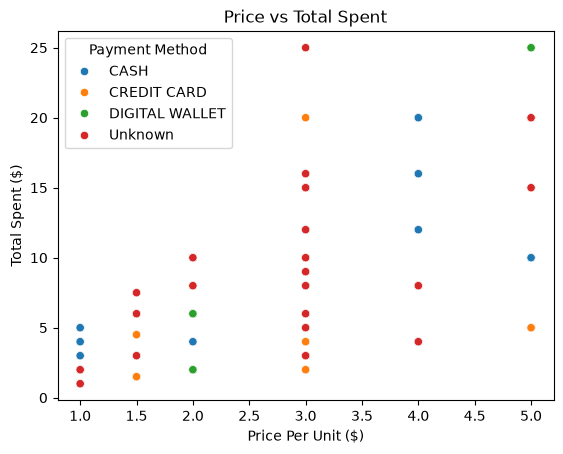

In [226]:
# Price with Total Spent
sns.scatterplot(data=df, x="Price Per Unit", y="Total Spent", hue="Payment Method")
plt.title("Price vs Total Spent")
plt.xlabel("Price Per Unit ($)")
plt.ylabel("Total Spent ($)")
plt.show()

Total Spent increases in discrete multiples of Price Per Unit, confirming that customers buy items in whole quantities (ranging from 1 to 5 items).

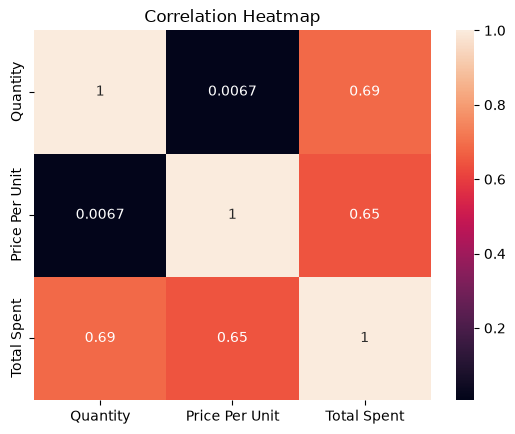

In [227]:
sns.heatmap(df[["Quantity", "Price Per Unit", "Total Spent"]].corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

Quantity with Total Spent and Price Per Unit with Total Spent have a realtion between them.

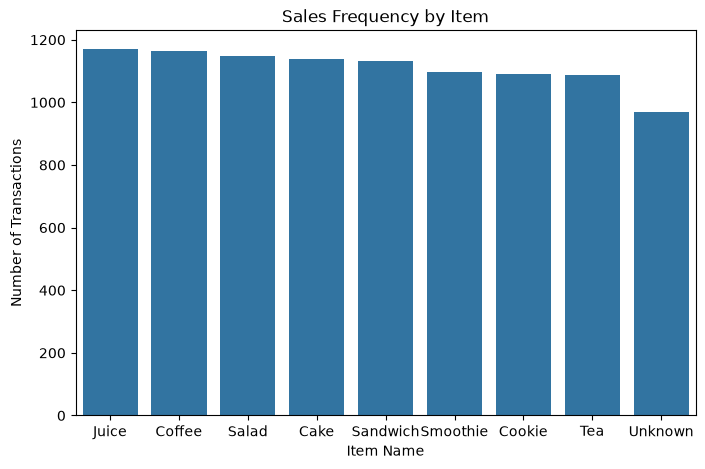

In [228]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Item", order=df["Item"].value_counts().index)
plt.title("Sales Frequency by Item")
plt.xlabel("Item Name")
plt.ylabel("Number of Transactions")
plt.show()

Coffee is the most frequently purchased item by a significant margin.

In [229]:
# remove Unknown locations
analysis_df = df[df["Location"] != "Unknown"]

# vector form for df
vector_matrix = analysis_df.pivot_table(
    index="Location", columns="Item", values="Total Spent", aggfunc="sum"
).fillna(0)

similarity_scores = cosine_similarity(vector_matrix)
similarity_df = pd.DataFrame(
    similarity_scores, index=vector_matrix.index, columns=vector_matrix.index
)
similarity_df

Location,IN-STORE,TAKEAWAY
Location,,
IN-STORE,1.000000,0.997325
TAKEAWAY,0.997325,1.000000


In [230]:
df.to_csv(r"D:\SapphireWork\data\processed\cleaned_transactions.csv", index=False)

### Before / After Summary
- **Before:** 10,000 rows, Missing values across almost all columns, Prices and Quantities stored as text with symbols like '$', Categories had inconsistent casing (e.g. "UNKNOWN", "ERROR", so I converted them to "Unknown").
- **After:** Duplicates removed, 0 unhandled nulls, Correct numeric and datetime types applied, Categories standardized, 2 new features (Month, Is_Weekend) added.

### Key Insights
1. **Coffee Dominance:** Coffee is the highest volume driver for the cafe.
2. **Revenue Drivers:** Higher-priced items like Cake and Sandwiches contribute disproportionately to total revenue despite lower volume.
3. **Data Quality Issues:** Missing data was heavily prevalent in Payment Method and Location, highlighting a need for better point-of-sale data validation.

### Data Ethics & PII Note
After reviewing the columns (Transaction ID, Item, Quantity, Price, Location, Payment Method, Date), **there is no Personal Identifiable Information (PII)** such as customer names, email addresses, or credit card numbers present in this dataset. In a real-world scenario, if "Payment Method" included full credit card details or if we tracked customer loyalty IDs linked to names, those columns would require strict access control, hashing, or masking before any analysis.
